# FormFactor 財務分析 — Step 3b：市場結構分析

Step 3a 比的是「測試設備產業」的同業。這一步要回答更直接的問題：

1. **FormFactor 的錢從哪裡來？** 營收結構（晶圓代工與邏輯、DRAM、Flash、系統）
2. **在探針卡市場的地位？** 和真正的直接對手（Technoprobe、MJC、中華精測）比較市占率與獲利
3. **上下游是誰？** 供應商、客戶、終端需求
4. **下一步該往哪裡發展？**

### 這一步的資料不一樣：手動收集

前面的資料都來自 SEC 的 API，格式統一。但市場分析需要的資料散落在：
- 公司年報（10-K）、季報（10-Q）、法說會新聞稿
- 外國公司的財報（歐元、日圓、新台幣）
- 市調機構的報告（每家估計方法不同）

這些要**手動整理成 CSV**，放在 `data/research/`。每一列都有 `source` 欄位寫明出處，這叫做**資料血緣 (data lineage)**：
任何人看到一個數字，都能追回它從哪裡來。這是專業分析報告的基本要求。

| 檔案 | 內容 |
|---|---|
| `form_revenue_by_market.csv` | FormFactor 按市場分的營收 |
| `probe_card_peers.csv` | 探針卡同業的營收與淨利（當地貨幣） |
| `fx_rates.csv` | 年平均匯率（美國國稅局 IRS 公布） |
| `market_facts.csv` | 市場規模、地區、客戶集中度等數據 |
| `supply_chain.csv` | 上下游關係 |

可以用 Excel 或 VS Code 打開這些 CSV 看看。

## 0. 環境設定與讀取資料

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BASE = Path.cwd()
RES_DIR = BASE / "data" / "research"
OUT_DIR = BASE / "data" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = BASE / "data" / "formfactor.db"

files = ["form_revenue_by_market", "probe_card_peers", "fx_rates", "market_facts", "supply_chain"]
data = {name: pd.read_csv(RES_DIR / f"{name}.csv") for name in files}
for name, df in data.items():
    print(f"{name:25s} {df.shape[0]:3d} 列 × {df.shape[1]} 欄")

form_revenue_by_market     28 列 × 7 欄
probe_card_peers            8 列 × 10 欄
fx_rates                   20 列 × 4 欄
market_facts               21 列 × 6 欄
supply_chain               13 列 × 5 欄


### 0.1 檢查缺值：哪些資料還沒填？

手動收集的資料最常見的問題就是**缺漏**。先找出來，不要讓空白默默影響後面的計算。

In [3]:
rev_mkt = data["form_revenue_by_market"]
rev_mkt[rev_mkt["revenue_musd"].isna()][["period", "market", "source", "note"]]

,period,market,source,note


### ✏️ 練習：自己從 10-K 填入 2022、2023 年的資料

上面這 8 列是空的。這是分析師的日常工作：**打開原始文件，找到表格，把數字抄進資料檔**。

1. 用瀏覽器打開 FormFactor FY2023 的 10-K：
   `https://www.sec.gov/Archives/edgar/data/1039399/000103939924000007/form-20231230.htm`
2. `Ctrl + F` 搜尋 **`Foundry & Logic`**，找到 MD&A（管理層討論與分析）裡「Revenues by market」的表格
3. 表格有 2023 和 2022 兩欄，單位通常是**千美元**，要除以 1,000 換成百萬美元
4. 用 Excel 或 VS Code 打開 `data/research/form_revenue_by_market.csv`，把數字填進 `revenue_musd`，`source` 改成 `FORM FY2023 10-K`
5. 存檔後，**從第 0 節重新執行**

**驗證方法**：四個市場加起來，要等於 Step 1 抓到的總營收（2023 年 663.1、2022 年 747.9）。第 2 節的程式會自動幫你檢查。

沒填也可以繼續往下跑，程式會跳過空白的年份。

## 1. 放進資料庫

這些是小型的參考資料表，每次都從 CSV 整個重新載入，所以這裡用 `if_exists="replace"` 就好。
（`financials` 那種大表才需要先設計結構、設主鍵，再 `append`。）

In [4]:
conn = sqlite3.connect(DB_PATH)
def q(sql):
    return pd.read_sql_query(sql, conn)

table_names = {
    "form_revenue_by_market": "market_revenue",
    "probe_card_peers": "probe_peers",
    "fx_rates": "fx_rates",
    "market_facts": "market_facts",
    "supply_chain": "supply_chain",
}
for csv_name, table in table_names.items():
    data[csv_name].to_sql(table, conn, if_exists="replace", index=False)
conn.commit()
q("SELECT name, type FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY type, name")

,name,type
0,companies,table
1,financials,table
2,fx_rates,table
3,market_facts,table
4,market_revenue,table
5,metric_dictionary,table
6,one_time_items,table
7,probe_peers,table
8,supply_chain,table
9,fin_wide,view


## 2. FormFactor 的營收結構

### 2.1 各市場占比：`SUM() OVER (PARTITION BY ...)`

要算「DRAM 占當年營收幾 %」，需要**分母 = 當年四個市場的合計**。

`SUM(revenue_musd) OVER (PARTITION BY period)` 會算出每個期間的合計，**但保留每一列**（不像 `GROUP BY` 會把列壓縮）。
所以每一列都能直接除以自己期間的合計。

In [5]:
mix = q('''
SELECT period, market, revenue_musd,
       SUM(revenue_musd) OVER (PARTITION BY period)                    AS period_total,
       100.0 * revenue_musd / SUM(revenue_musd) OVER (PARTITION BY period) AS share_pct
FROM market_revenue
WHERE revenue_musd IS NOT NULL
ORDER BY period, revenue_musd DESC
''')
mix.round(1)

,period,market,revenue_musd,period_total,share_pct
0,2022,Foundry & Logic,409.20,747.90,54.70
1,2022,Systems,156.50,747.90,20.90
2,2022,DRAM,133.40,747.90,17.80
3,2022,Flash,48.80,747.90,6.50
4,2022H1,Foundry & Logic,236.50,401.10,59.00
5,2022H1,Systems,73.40,401.10,18.30
6,2022H1,DRAM,71.30,401.10,17.80
7,2022H1,Flash,19.90,401.10,5.00
8,2023,Foundry & Logic,363.50,663.10,54.80
9,2023,Systems,165.20,663.10,24.90


In [6]:
# 樞紐成「市場 × 期間」，比較容易看出變化

mix_wide = mix.pivot(index="market", columns="period", values="share_pct").round(1)
mix_wide = mix_wide[[c for c in ["2022H1", "2023H1", "2022", "2023", "2024", "2025", "TTM 2026Q2"] if c in mix_wide]]
mix_wide.loc[["Foundry & Logic", "DRAM", "Flash", "Systems"]]

period,2022H1,2023H1,2022,2023,2024,2025,TTM 2026Q2
market,,,,,,,
Foundry & Logic,59.00,56.80,54.70,54.80,49.90,47.10,46.30
DRAM,17.80,15.60,17.80,17.20,29.80,31.50,34.30
Flash,5.00,2.70,6.50,3.10,2.30,2.60,2.20
Systems,18.30,25.00,20.90,24.90,18.00,18.70,17.20


### 2.2 交叉驗證：手動資料 vs SEC 資料

**兩個獨立來源的數字要能對得上。** 把手動收集的「四個市場合計」和 Step 1 從 SEC 抓的「總營收」用 `JOIN` 放在一起比較。

`CAST(period AS INTEGER)`：`period` 是文字（因為有 "2023H1" 這種值），要轉成整數才能和 `fiscal_year` 對應。

In [7]:
q('''
WITH manual AS (
    SELECT CAST(period AS INTEGER) AS fiscal_year, SUM(revenue_musd) AS manual_total
    FROM market_revenue
    WHERE period_type = 'FY' AND revenue_musd IS NOT NULL
    GROUP BY period
)
SELECT m.fiscal_year,
       ROUND(m.manual_total, 1)                    AS manual_total_musd,
       ROUND(f.value / 1e6, 1)                     AS sec_revenue_musd,
       ROUND(m.manual_total - f.value / 1e6, 2)    AS difference,
       CASE WHEN ABS(m.manual_total - f.value / 1e6) < 1 THEN '✅' ELSE '❌ 請檢查' END AS check_result
FROM manual m
JOIN financials f
  ON f.ticker = 'FORM' AND f.metric = 'revenue' AND f.fiscal_year = m.fiscal_year
ORDER BY m.fiscal_year
''')

,fiscal_year,manual_total_musd,sec_revenue_musd,difference,check_result
0,2022,747.90,747.90,0.00,✅
1,2023,663.10,663.10,0.00,✅
2,2024,763.60,763.60,0.00,✅
3,2025,785.00,785.00,0.01,✅


### 2.3 景氣下行時，哪個市場跌最多？

用 2022 上半年 vs 2023 上半年比較（2023 年是產業低谷）。這裡用**自我連接 (self-join)**：同一張表 `JOIN` 自己，把兩個期間放在同一列。

In [8]:
q('''
SELECT a.market,
       a.revenue_musd                                          AS h1_2022,
       b.revenue_musd                                          AS h1_2023,
       ROUND(100.0 * (b.revenue_musd - a.revenue_musd) / a.revenue_musd, 1) AS change_pct
FROM market_revenue a
JOIN market_revenue b ON a.market = b.market
WHERE a.period = '2022H1' AND b.period = '2023H1'
ORDER BY change_pct
''')

,market,h1_2022,h1_2023,change_pct
0,Flash,19.91,8.75,-56.10
1,DRAM,71.28,50.35,-29.40
2,Foundry & Logic,236.50,183.53,-22.40
3,Systems,73.39,80.73,10.00


### 2.4 畫圖：各市場營收的變化

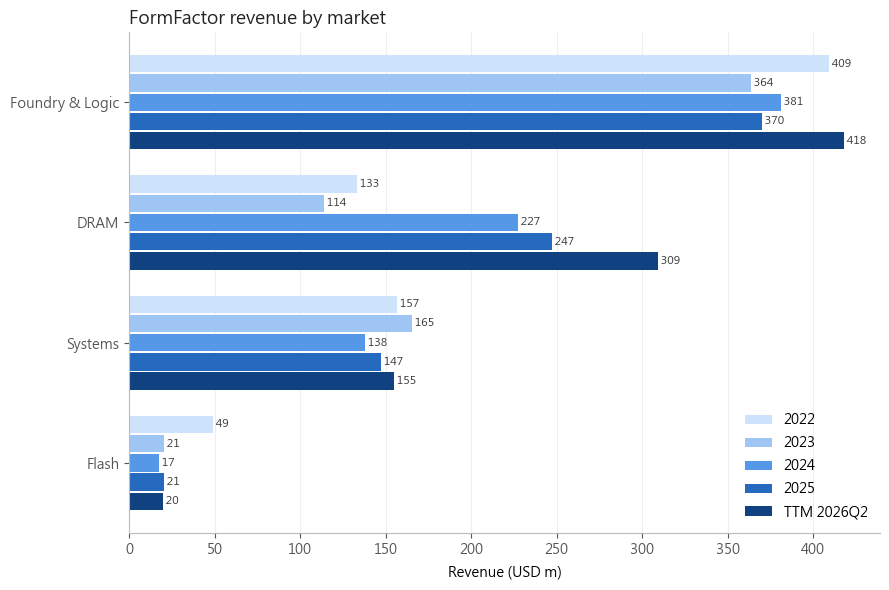

In [11]:
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Noto Sans CJK TC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bbbbbb")
    ax.set_axisbelow(True)
    ax.tick_params(colors="#555555")

periods = [p for p in ["2022", "2023", "2024", "2025", "TTM 2026Q2"] if p in set(mix["period"])]
markets = ["Foundry & Logic", "DRAM", "Systems", "Flash"]
shades = ["#cde2fb", "#9ec5f4", "#5598e7", "#256abf", "#104281"]     # 同一色相由淺到深 = 時間由舊到新

n = len(periods)
bar_h = 0.8 / n                      # 每組總高度固定 0.8，期數越多每條越細，不會和隔壁組重疊

fig, ax = plt.subplots(figsize=(9, 6))
for i, p in enumerate(periods):
    d = mix[mix["period"] == p].set_index("market").reindex(markets)["revenue_musd"]
    ys = [y + (i - (n - 1) / 2) * bar_h for y in range(len(markets))]
    ax.barh(ys, d.values, height=bar_h * 0.9, color=shades[i], label=p)   # 0.9：條與條之間留縫
    for y, v in zip(ys, d.values):
        ax.text(v, y, f" {v:.0f}", va="center", fontsize=8, color="#333333")
ax.set_yticks(range(len(markets)))
ax.set_yticklabels(markets)
ax.invert_yaxis()
ax.set_xlabel("Revenue (USD m)")
ax.set_title("FormFactor revenue by market", loc="left", fontsize=13, color="#222222")
ax.grid(axis="x", color="#eeeeee")
ax.legend(frameon=False, loc="lower right")
style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "form_revenue_by_market.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 探針卡同業：換算成美元

Technoprobe 用歐元、MJC 用日圓、中華精測用新台幣報告營收，**要先換成同一種貨幣才能比較**。

匯率表 `fx_rates` 存的是「1 美元 = 多少當地貨幣」，所以：
```
美元營收 = 當地貨幣營收 ÷ 匯率
```
用 `JOIN ... ON currency AND year` 把每一列配上當年的匯率。**同時用兩個條件 JOIN**，是這段 SQL 的重點。

In [12]:
conn.execute("DROP VIEW IF EXISTS probe_peers_usd")
conn.execute('''
CREATE VIEW probe_peers_usd AS
SELECT p.company, p.ticker, p.country, p.fiscal_year, p.currency,
       p.revenue_local_m,
       x.units_per_usd,
       p.revenue_local_m / x.units_per_usd     AS revenue_usd_m,
       p.net_income_local_m / x.units_per_usd  AS net_income_usd_m,
       p.revenue_scope
FROM probe_peers p
JOIN fx_rates x
  ON p.currency = x.currency AND p.fiscal_year = x.year
''')
q("SELECT company, fiscal_year, currency, revenue_local_m, units_per_usd, ROUND(revenue_usd_m, 1) AS revenue_usd_m FROM probe_peers_usd ORDER BY fiscal_year DESC, revenue_usd_m DESC")

,company,fiscal_year,currency,revenue_local_m,units_per_usd,revenue_usd_m
0,Technoprobe,2025,EUR,628.40,0.89,709.30
1,FormFactor,2025,USD,637.90,1.00,637.90
2,Micronics Japan,2025,JPY,"70,173.00",149.63,469.00
3,Chunghwa Precision Test,2025,TWD,"4,806.00",31.17,154.20
4,FormFactor,2024,USD,625.96,1.00,626.00
5,Technoprobe,2024,EUR,543.20,0.92,587.90
6,Micronics Japan,2024,JPY,"55,643.00",151.35,367.60
7,Chunghwa Precision Test,2024,TWD,"3,605.00",32.12,112.20


### 3.1 成長率：當地貨幣 vs 美元

匯率會影響成長率。例如歐元 2025 年對美元升值，Technoprobe 的歐元營收換成美元後，**成長看起來會比較高**。
分析外國公司時，要分清楚哪些是**本業成長**、哪些是**匯率效果**。

In [13]:
growth = q('''
SELECT company, fiscal_year,
       ROUND(100.0 * (revenue_local_m - LAG(revenue_local_m) OVER w) / LAG(revenue_local_m) OVER w, 1) AS growth_local_pct,
       ROUND(100.0 * (revenue_usd_m   - LAG(revenue_usd_m)   OVER w) / LAG(revenue_usd_m)   OVER w, 1) AS growth_usd_pct
FROM probe_peers_usd
WINDOW w AS (PARTITION BY company ORDER BY fiscal_year)
''')
growth = growth.dropna()
growth["fx_effect_pct"] = (growth["growth_usd_pct"] - growth["growth_local_pct"]).round(1)
growth.sort_values("growth_local_pct", ascending=False)

,company,fiscal_year,growth_local_pct,growth_usd_pct,fx_effect_pct
1,Chunghwa Precision Test,2025,33.30,37.40,4.10
5,Micronics Japan,2025,26.10,27.60,1.50
7,Technoprobe,2025,15.70,20.60,4.90
3,FormFactor,2025,1.90,1.90,0.00


## 4. 市占率

### 4.1 兩種估計方法

| 方法 | 做法 | 優缺點 |
|---|---|---|
| **由上而下 (top-down)** | 公司營收 ÷ 市調機構估計的市場規模 | 簡單，但市場規模各家估法差很多 |
| **由下而上 (bottom-up)** | 把主要廠商營收加總，看各家占多少 | 用的是真實財報，但只涵蓋列入的公司 |

**兩種都算，互相對照**（這叫三角驗證 triangulation）。

市場規模：Mordor Intelligence 估計 2026 年 30.4 億美元、年成長 9.35%，往回推 2025 年約為 30.4 ÷ 1.0935 ≈ **27.8 億美元**（這是推估值）。

In [14]:
mkt_2026 = q("SELECT value FROM market_facts WHERE item = 'Global probe card market' AND year = 2026")["value"].iloc[0]
cagr = q("SELECT value FROM market_facts WHERE item LIKE '%CAGR%'")["value"].iloc[0]
mkt_2025_musd = mkt_2026 / (1 + cagr / 100) * 1000
print(f"推估 2025 年探針卡市場規模：約 {mkt_2025_musd:,.0f} 百萬美元")

share = q(f'''
SELECT company, fiscal_year,
       ROUND(revenue_usd_m, 1)                                                        AS revenue_usd_m,
       ROUND(100.0 * revenue_usd_m / {mkt_2025_musd}, 1)                              AS share_of_market_pct,
       ROUND(100.0 * revenue_usd_m / SUM(revenue_usd_m) OVER (PARTITION BY fiscal_year), 1) AS share_of_group_pct,
       RANK() OVER (PARTITION BY fiscal_year ORDER BY revenue_usd_m DESC)             AS rank_in_year
FROM probe_peers_usd
ORDER BY fiscal_year DESC, revenue_usd_m DESC
''')
share.loc[share["fiscal_year"] != 2025, "share_of_market_pct"] = None   # 市場規模只推估了 2025 年
share

推估 2025 年探針卡市場規模：約 2,780 百萬美元


,company,fiscal_year,revenue_usd_m,share_of_market_pct,share_of_group_pct,rank_in_year
0,Technoprobe,2025,709.30,25.50,36.00,1
1,FormFactor,2025,637.90,22.90,32.40,2
2,Micronics Japan,2025,469.00,16.90,23.80,3
3,Chunghwa Precision Test,2025,154.20,5.50,7.80,4
4,FormFactor,2024,626.00,NaN,37.00,1
5,Technoprobe,2024,587.90,NaN,34.70,2
6,Micronics Japan,2024,367.60,NaN,21.70,3
7,Chunghwa Precision Test,2024,112.20,NaN,6.60,4


> ⚠️ **解讀前必看：營收範圍不完全相同**
> - FormFactor 只算**探針卡部門**（不含系統），其他三家是**全公司營收**
> - Technoprobe 的營收包含 2024 年從 Teradyne 買來的 **Device Interface Solutions** 業務，不全是探針卡
> - MJC 和中華精測除了探針卡，也有少量其他產品
>
> 所以其他公司的「探針卡營收」其實會比表上**略低**。比較排名時要把這點寫進報告。

### 4.2 市場集中度：HHI 指數

**HHI (Herfindahl-Hirschman Index)** = 每家公司市占率（%）的平方加總。

- 完全壟斷（一家 100%）：100² = 10,000
- 越多家平均瓜分，數字越小
- 美國司法部 2023 年併購指引：**HHI 超過 1,800 = 高度集中**

這裡用「4 家列入公司」內部的占比計算，所以只代表這 4 家之間的集中程度，不是整個市場的 HHI。

In [15]:
q('''
WITH s AS (
    SELECT fiscal_year,
           100.0 * revenue_usd_m / SUM(revenue_usd_m) OVER (PARTITION BY fiscal_year) AS share_pct
    FROM probe_peers_usd
)
SELECT fiscal_year, ROUND(SUM(share_pct * share_pct), 0) AS hhi_within_group
FROM s
GROUP BY fiscal_year
ORDER BY fiscal_year
''')

,fiscal_year,hhi_within_group
0,2024,"3,086.00"
1,2025,"2,972.00"


### 4.3 畫圖：探針卡營收（美元）

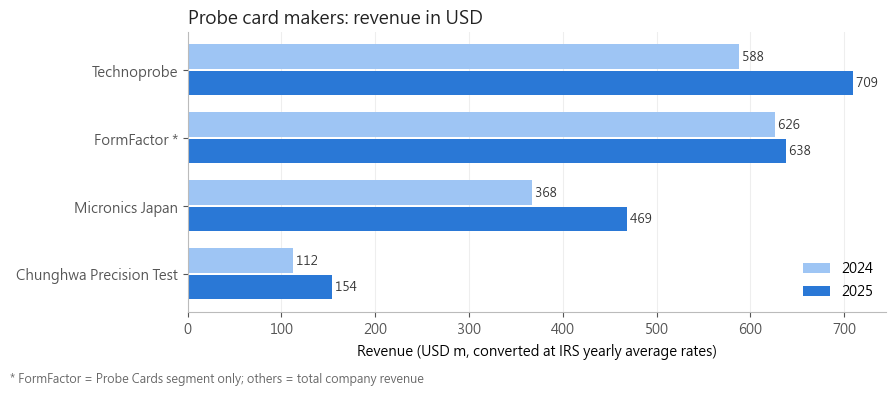

In [16]:
pv = q("SELECT company, fiscal_year, revenue_usd_m FROM probe_peers_usd").pivot(
    index="company", columns="fiscal_year", values="revenue_usd_m")
pv = pv.sort_values(pv.columns.max(), ascending=False)
years = list(pv.columns)
year_colors = {years[0]: "#9ec5f4", years[-1]: "#2a78d6"}   # 舊 = 淺，新 = 深

fig, ax = plt.subplots(figsize=(9, 3.8))
bar_h = 0.36
for i, yr in enumerate(years):
    ys = [y + (i - 0.5) * (bar_h + 0.03) for y in range(len(pv))]
    ax.barh(ys, pv[yr].values, height=bar_h, color=year_colors[yr], label=str(yr))
    for y, v in zip(ys, pv[yr].values):
        ax.text(v, y, f" {v:.0f}", va="center", fontsize=9, color="#333333")
labels = [f"{c} *" if c == "FormFactor" else c for c in pv.index]
ax.set_yticks(range(len(pv)))
ax.set_yticklabels(labels)
ax.invert_yaxis()   # 營收最大的放最上面；每組裡舊年度在上、新年度在下
ax.set_xlabel("Revenue (USD m, converted at IRS yearly average rates)")
ax.set_title("Probe card makers: revenue in USD", loc="left", fontsize=13, color="#222222")
ax.grid(axis="x", color="#eeeeee")
ax.legend(frameon=False, loc="lower right")
style(ax)
fig.text(0.01, -0.02, "* FormFactor = Probe Cards segment only; others = total company revenue", fontsize=8.5, color="#666666")
plt.tight_layout()
plt.savefig(OUT_DIR / "probe_card_revenue_usd.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 獲利能力：探針卡同業賺多少？

Step 3a 我們推測「FormFactor 毛利低，可能是探針卡這門生意本身的特性」。**現在可以用直接對手來檢驗這個假設。**

用 `UNION ALL` 把兩個來源疊在一起：FormFactor 的淨利來自 SEC 資料（`fin_wide`），同業的來自手動資料。
`UNION ALL` 要求兩邊的**欄位數量和順序相同**。

In [17]:
q('''
SELECT 'FormFactor' AS company, fiscal_year,
       ROUND(revenue / 1e6, 1)                    AS revenue_usd_m,
       ROUND(net_income / 1e6, 1)                 AS net_income_usd_m,
       ROUND(100.0 * net_income / revenue, 1)     AS net_margin_pct
FROM fin_wide
WHERE ticker = 'FORM' AND fiscal_year IN (2024, 2025)

UNION ALL

SELECT company, fiscal_year,
       ROUND(revenue_usd_m, 1),
       ROUND(net_income_usd_m, 1),
       ROUND(100.0 * net_income_usd_m / revenue_usd_m, 1)
FROM probe_peers_usd
WHERE net_income_usd_m IS NOT NULL

ORDER BY fiscal_year DESC, net_margin_pct DESC
''')

,company,fiscal_year,revenue_usd_m,net_income_usd_m,net_margin_pct
0,Micronics Japan,2025,469.00,80.60,17.20
1,Technoprobe,2025,709.30,111.50,15.70
2,FormFactor,2025,785.00,54.40,6.90
3,Micronics Japan,2024,367.60,58.20,15.80
4,Technoprobe,2024,587.90,68.00,11.60
5,FormFactor,2024,763.60,69.60,9.10


In [19]:
seg = pd.read_csv(RES_DIR / "segment_gross_margin.csv")
seg.pivot(index="segment", columns="fiscal_year", values="gross_margin_pct")

fiscal_year,2022,2023,2024,2025
segment,,,,
Corporate and Other,NaN,NaN,NaN,NaN
Probe Cards,39.80,37.20,41.40,40.50
Systems,51.70,51.30,43.20,41.80


> 這裡 FormFactor 用的是**全公司**營收和淨利（含系統部門），和同業的全公司數字比較才公平。
> 淨利率會受稅率、利息、一次性項目影響，所以只能當作粗略比較。更好的做法是比較**營業利益率**：MJC 2025 年營業利益為 165.4 億日圓，可以自己算算看營業利益率是多少。

## 6. 上下游關係

In [18]:
q("SELECT tier, role, name, detail FROM supply_chain")

,tier,role,name,detail
0,Upstream,Materials & components,Ceramic and organic substrates,Sole or limited source; purchase orders rather than long-term contracts
1,Upstream,Materials & components,Complex printed circuit boards,Sole or limited source; some minimum order quantities
2,Upstream,Materials & components,Contact elements and interconnects,Sole or limited source
3,Company,Probe card manufacturing,FormFactor - Livermore CA & Beaverton OR,Primary probe card facilities
4,Company,Systems manufacturing,FormFactor - Boulder CO; Thiendorf / Munich / Karlsruhe Germany,"Probe stations, thermal and cryogenic systems"
5,Competitor,Probe cards,Technoprobe; Micronics Japan; Japan Electronic Materials; MPI; Korea Instrum...,Named probe card competitors
6,Competitor,Probe stations,MPI; Semishare; STAr Technologies; Tokyo Electron; Wentworth Laboratories,Named systems competitors
7,Downstream,Customer (DRAM / HBM),SK hynix,Largest customer in FY2025 (about 22.9% of revenue)
8,Downstream,Customer (Foundry & Logic),Intel,Over 10% of revenue in parts of 2024-2025
9,Downstream,Customer (Foundry),TSMC,Over 10% of revenue in at least one 2025 quarter


### 產業鏈示意

```
 上游（供應商）                    FormFactor                      下游（客戶）              終端需求
┌──────────────────────┐    ┌──────────────────────┐    ┌──────────────────────┐    ┌──────────────────┐
│ 陶瓷／有機基板          │    │ 探針卡                 │    │ 記憶體：SK hynix、     │    │ AI 加速器（HBM）   │
│ 多層印刷電路板          │ ─▶ │  Livermore, Beaverton │ ─▶ │        Samsung       │ ─▶ │ 資料中心、HPC      │
│ 接觸元件、連接器        │    │ 系統（探針台、低溫系統）  │    │ 邏輯／代工：Intel、     │    │ 手機、PC          │
│ （多為單一或少數來源）   │    │  Boulder, 德國         │    │        TSMC          │    │ 共同封裝光學 CPO   │
└──────────────────────┘    └──────────────────────┘    └──────────────────────┘    └──────────────────┘
                                       ▲
                     競爭者：Technoprobe、MJC、JEM、MPI、韓國 Korea Instrument 等
```

**觀察重點**：
- **上游議價能力**：關鍵材料是單一或少數供應商，而且多用採購單、沒有長期合約 → 供應中斷風險
- **下游集中度**：最大客戶（SK hynix）約占 23% 營收 → 客戶議價能力強，單一客戶減單影響大
- **客戶結構轉變**：從以 Intel（邏輯）為主，轉向以 SK hynix（記憶體 / HBM）為主

## 7. 其他市場數據

In [20]:
q("SELECT topic, item, year, value, unit, source FROM market_facts ORDER BY topic, item, year")

,topic,item,year,value,unit,source
0,concentration,Top-3 vendors share of revenue,2025,60.00,%,Mordor Intelligence (approximate)
1,customers,FORM largest single customer share of revenue,2025,22.90,%,FORM FY2025 10-K (largest customer; SK hynix per quarterly customer table)
2,customers,Intel share of FORM revenue (six months),2022,20.90,%,FORM 10-Q six months ended 2023-07-01 (prior-year column)
3,customers,Intel share of FORM revenue (six months),2023,17.20,%,FORM 10-Q six months ended 2023-07-01
4,geography,FORM China share of revenue,2023,14.00,%,FORM FY2025 10-K
5,geography,FORM China share of revenue,2024,14.00,%,FORM FY2025 10-K
6,geography,FORM China share of revenue,2025,7.00,%,FORM FY2025 10-K
7,geography,FORM international share of revenue,2023,74.00,%,FORM FY2025 10-K
8,geography,FORM international share of revenue,2024,76.00,%,FORM FY2025 10-K
9,geography,FORM international share of revenue,2025,81.00,%,FORM FY2025 10-K


## 8. 輸出

In [21]:
mix.to_csv(OUT_DIR / "form_revenue_mix.csv", index=False)
share.to_csv(OUT_DIR / "probe_card_market_share.csv", index=False)
growth.to_csv(OUT_DIR / "probe_card_growth.csv", index=False)
conn.close()
print("✅ 輸出到", OUT_DIR)

✅ 輸出到 C:\Users\User\Documents\FormFactor_Analysis\data\analysis


## 📝 解讀問題：從市場結構到投資建議

先自己根據上面的結果回答，這就是報告「市場分析」和「發展方向建議」兩段的內容。

**營收結構**
1. FormFactor 最大的市場是哪個？DRAM 的占比從 2024 到最近 12 個月有什麼變化？背後的驅動力是什麼？（提示：HBM）
2. 2023 年景氣下行時，哪個市場跌最多？哪個市場反而成長？這說明系統部門扮演什麼角色？

**市場地位**
3. 換算成美元後，FormFactor 的探針卡營收還是第一名嗎？2024 到 2025 年，誰成長最快？FormFactor 的市占率是上升還是下降？
4. 營收範圍不同（FormFactor 只算探針卡，Technoprobe 含 DIS 業務），會怎麼影響你的結論？

**獲利能力**
5. 探針卡同業的淨利率是 FormFactor 的幾倍？這個結果**支持還是推翻** Step 3a「探針卡本來就是低毛利生意」的假設？如果推翻，FormFactor 獲利偏低的原因可能是什麼？

**上下游與風險**
6. 客戶集中、關鍵材料單一來源、中國營收占比下降，各代表什麼風險或機會？

**下一步發展方向（你的建議）**
7. 綜合財務、同業、市場三個面向，你會建議 FormFactor 把資源投在哪裡？可以從這幾個方向思考：
   - **HBM / DRAM**：擴大產能，鞏固在 SK hynix 等記憶體大廠的地位？
   - **共同封裝光學 (CPO)**：收購 Keystone Photonics 後，能否成為新的成長引擎？
   - **提升毛利率**：管理層說要「在現有廠房內擴產」來改善毛利，2026 年第一季毛利率指引 45%，這個方向可信嗎？
   - **降低客戶集中度**：拓展更多晶圓代工 / 邏輯客戶？
   - **併購**：是否該收購同業或上游供應商，取得技術或確保供應？

**下一步 → Step 4 技術分析**：探針卡技術路線（MEMS、垂直探針、細間距）、HBM 與先進封裝的測試挑戰、CPO 光學測試、材料突破的可能性。